# 05 · Hotel price-adjustment behaviour & inflation pass-through

Parts 5 and 6 of the brief.

**Caveat up front:** `average_rate` is a *reported monthly average* per
category, not a posted menu price, so it moves nearly every month. A menu-cost
"frequency of adjustment" is therefore close to 1 and not very informative; the
meaningful margins are the **size, sign and dispersion** of the monthly change
and how they co-move with inflation. We report frequency at several thresholds
anyway, then focus on magnitude and pass-through.

**Input** `03_analysis_panel.parquet` →
**Output** `outputs/tables/table2_passthrough.csv`,
`price_adjustment_stats.csv`, `passthrough_by_regime.csv`,
`outputs/figures/05_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("05_price_adj")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
df = df[df.in_window == 1].copy()
df["dln_cpi_gba"] = np.log1p(df["infl_mom_gba"] / 100)
df["dln_cpi_nac"] = np.log1p(df["infl_mom_nac"] / 100)
CORE = C.CORE_CATEGORIES
ALLc = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
HAC = dict(cov_type="HAC", cov_kwds={"maxlags": 6})

## 1 · Price-change distribution & frequency, by category

Baseline sample: in-window, **COVID (2020-03…2022-12) excluded** so the
reopening jumps don't masquerade as price adjustments.

In [2]:
base = df[df.covid_any == 0]
rows = []
for cat, s in base.groupby("hotel_category"):
    if cat not in ALLc:
        continue
    d = s["dln_average_rate"].dropna()
    pos, neg = d[d > 0], d[d < 0]
    rows.append(dict(
        hotel_category=cat, label=LAB[cat], n=len(d),
        freq_change_any=(d.abs() > 0).mean(),
        freq_change_gt_0p1pct=(d.abs() > 0.001).mean(),
        freq_change_gt_1pct=(d.abs() > 0.01).mean(),
        share_up=(d > 0).mean(), share_down=(d < 0).mean(),
        mean_pos_pct=pos.mean() * 100, mean_neg_pct=neg.mean() * 100,
        median_abs_pct=d.abs().median() * 100, sd_pct=d.std() * 100,
        p10_pct=d.quantile(.1) * 100, p90_pct=d.quantile(.9) * 100,
        share_faster_than_cpi=(d > s.loc[d.index, "dln_cpi_gba"]).mean(),
        share_slower_than_cpi=(d < s.loc[d.index, "dln_cpi_gba"]).mean(),
    ))
padj = pd.DataFrame(rows).set_index("hotel_category").round(3)
padj.to_csv(C.OUT_TAB / "price_adjustment_stats.csv")
LOG.log("write", "price_adjustment_stats.csv", len(padj))
padj

  [05_price_adj] write                  price_adjustment_stats.csv              6  


,label,n,freq_change_any,freq_change_gt_0p1pct,freq_change_gt_1pct,share_up,share_down,mean_pos_pct,mean_neg_pct,median_abs_pct,sd_pct,p10_pct,p90_pct,share_faster_than_cpi,share_slower_than_cpi
hotel_category,,,,,,,,,,,,,,,
apart,Apart-hotel,77,1.0,0.974,0.870,0.792,0.208,7.746,-8.558,5.220,10.432,-5.178,15.094,0.506,0.481
boutique,Boutique,77,1.0,0.987,0.922,0.753,0.247,7.471,-4.522,5.361,8.045,-4.187,13.185,0.545,0.442
stars_1_2,1-2 star,76,1.0,0.987,0.921,0.776,0.224,6.600,-4.920,4.375,7.681,-2.533,10.923,0.487,0.500
stars_3,3 star,77,1.0,0.987,0.870,0.727,0.273,7.597,-4.233,4.801,8.022,-3.023,13.721,0.442,0.545
stars_4,4 star,77,1.0,0.987,0.870,0.753,0.247,7.343,-3.877,4.928,7.236,-4.390,13.699,0.468,0.519
stars_5,5 star,77,1.0,1.000,0.961,0.636,0.364,10.954,-7.103,6.485,13.775,-7.828,15.496,0.455,0.532


## 2 · Distribution of monthly price changes

  [05_price_adj] figure                 05_change_distribution.png                 


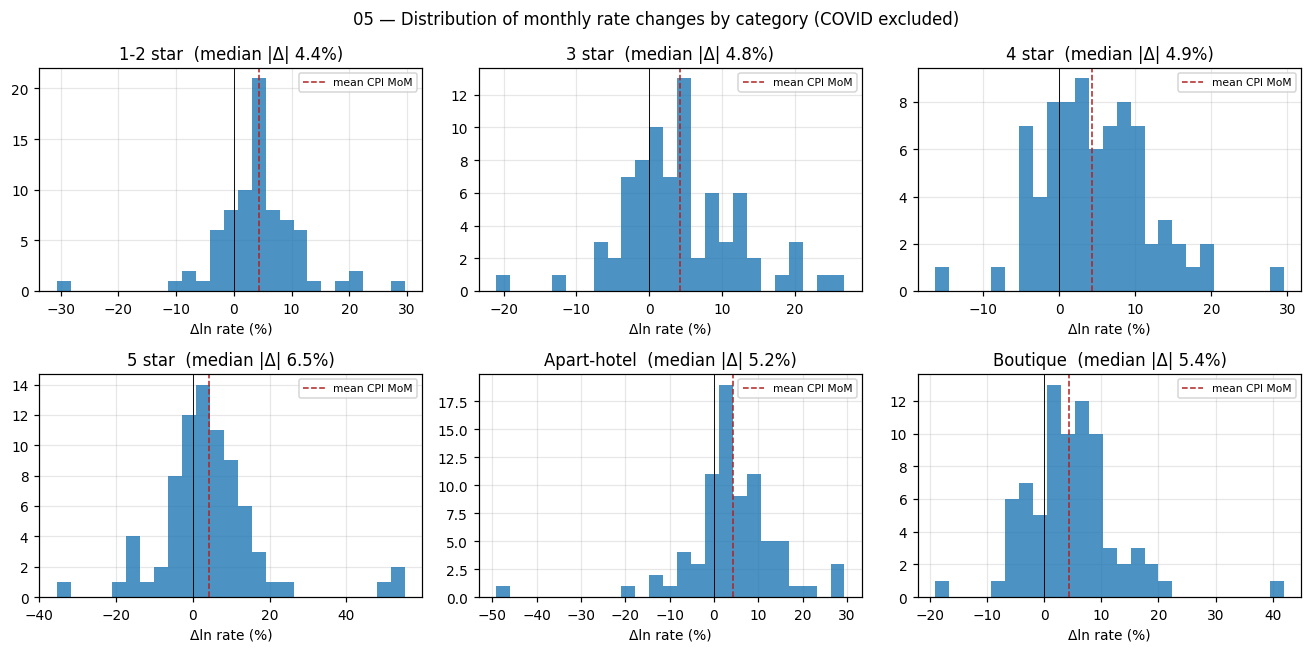

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, cat in zip(axes.ravel(), ALLc):
    d = base.loc[base.hotel_category == cat, "dln_average_rate"].dropna() * 100
    ax.hist(d, bins=25, alpha=.8)
    ax.axvline(0, color="k", lw=.6)
    ax.axvline(base.loc[base.hotel_category == cat, "dln_cpi_gba"].mean() * 100,
               color="firebrick", ls="--", lw=1, label="mean CPI MoM")
    ax.set_title(f"{LAB[cat]}  (median |Δ| {d.abs().median():.1f}%)")
    ax.set_xlabel("Δln rate (%)"); ax.legend(fontsize=7)
fig.suptitle("05 — Distribution of monthly rate changes by category (COVID excluded)")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "05_change_distribution.png")
LOG.log("figure", "05_change_distribution.png"); plt.show()

## 3 · Monthly pass-through ratio  PT_t = Δln(P_t) / Δln(CPI_t)

Mechanically unstable when Δln(CPI) is small, so we report it only for months
with CPI MoM > 2% and summarise with the **median**, not the mean.

In [4]:
pt = base[base.infl_mom_gba > 2].copy()
pt["PT"] = pt["dln_average_rate"] / pt["dln_cpi_gba"]
pt_summary = (pt[pt.hotel_category.isin(ALLc)]
              .groupby("hotel_category")["PT"]
              .agg(n="size", median="median", q25=lambda x: x.quantile(.25),
                   q75=lambda x: x.quantile(.75)).round(2))
LOG.log("passthrough_ratio", "median PT (CPI MoM>2%)",
        detail=pt_summary["median"].round(2).to_dict())
pt_summary

  [05_price_adj] passthrough_ratio      median PT (CPI MoM>2%)                     {'apart': 1.0, 'boutique': 1.1, 'stars_1_2': 0.89, 'stars_3': 0.72, 'stars_4': 1.0, 'stars_5': 0.77}


,n,median,q25,q75
hotel_category,,,,
apart,64,1.00,0.11,1.72
boutique,64,1.10,-0.26,1.88
stars_1_2,64,0.89,0.27,1.60
stars_3,64,0.72,-0.16,1.82
stars_4,64,1.00,0.26,2.30
stars_5,64,0.77,-0.37,2.52


## 4 · Regression pass-through  (per category)

* **Contemporaneous:** Δln P_t = α + β·Δln CPI_t + ε  (HAC/Newey–West SE, 6 lags)
* **Distributed lag (0–3):** cumulative pass-through = Σ β_k
* Three samples: `covid_excl` (2020-03…2022-12 out), `covid_excl + drop2022`
  already same, `ex_extreme` also drops |CPI MoM| > p90.

In [5]:
def fit_pt(s, lags=0):
    s = s.dropna(subset=["dln_average_rate", "dln_cpi_gba"]).sort_values("date")
    y = s["dln_average_rate"]
    X = pd.DataFrame({"dln_cpi_l0": s["dln_cpi_gba"]}, index=s.index)
    for k in range(1, lags + 1):
        X[f"dln_cpi_l{k}"] = s["dln_cpi_gba"].shift(k)
    XY = pd.concat([y, X], axis=1).dropna()
    if len(XY) < 20:
        return None
    m = sm.OLS(XY[y.name], sm.add_constant(XY[X.columns])).fit(**HAC)
    return m


res = []
for cat, s in df[df.hotel_category.isin(ALLc)].groupby("hotel_category"):
    samples = {
        "covid_excl": s[s.covid_any == 0],
        "ex_extreme": s[(s.covid_any == 0) &
                        (s.infl_mom_gba.abs() <= s.infl_mom_gba.abs().quantile(.90))],
        "incl_2022": s[s.covid_hole == 0],
    }
    for tag, ss in samples.items():
        m0 = fit_pt(ss, 0)
        m3 = fit_pt(ss, 3)
        if m0 is None:
            continue
        lagcols = [c for c in m3.params.index if c.startswith("dln_cpi_l")] if m3 is not None else []
        cum = float(m3.params[lagcols].sum()) if m3 is not None else np.nan
        res.append(dict(
            hotel_category=cat, label=LAB[cat], sample=tag, n=int(m0.nobs),
            beta_contemp=round(m0.params["dln_cpi_l0"], 3),
            se_contemp=round(m0.bse["dln_cpi_l0"], 3),
            t_contemp=round(m0.tvalues["dln_cpi_l0"], 2),
            r2=round(m0.rsquared, 3),
            beta_cum_0_3=round(cum, 3) if m3 is not None else np.nan,
        ))
tab2 = pd.DataFrame(res)
tab2.to_csv(C.OUT_TAB / "table2_passthrough.csv", index=False)
LOG.log("write", "table2_passthrough.csv", len(tab2))
tab2[tab2["sample"] == "covid_excl"].set_index("hotel_category")

  [05_price_adj] write                  table2_passthrough.csv                 18  


,label,sample,n,beta_contemp,se_contemp,t_contemp,r2,beta_cum_0_3
hotel_category,,,,,,,,
apart,Apart-hotel,covid_excl,76,0.893,0.146,6.13,0.108,0.771
boutique,Boutique,covid_excl,76,1.159,0.199,5.81,0.304,0.856
stars_1_2,1-2 star,covid_excl,75,0.854,0.125,6.85,0.183,0.784
stars_3,3 star,covid_excl,76,0.747,0.138,5.41,0.142,0.594
stars_4,4 star,covid_excl,76,1.085,0.160,6.77,0.332,0.800
stars_5,5 star,covid_excl,76,1.251,0.278,4.51,0.121,0.881


## 5 · Full Table 2 across samples

In [6]:
tab2.pivot_table(index=["hotel_category", "label"], columns="sample",
                 values=["beta_contemp", "beta_cum_0_3", "r2", "n"]).round(3)

beta_contemp                      beta_cum_0_3  \
sample                       covid_excl ex_extreme incl_2022   covid_excl   
hotel_category label                                                        
apart          Apart-hotel        0.893      1.925     0.991        0.771   
boutique       Boutique           1.159      1.103     1.184        0.856   
stars_1_2      1-2 star           0.854      0.335     0.854        0.784   
stars_3        3 star             0.747      1.554     0.841        0.594   
stars_4        4 star             1.085      1.807     1.132        0.800   
stars_5        5 star             1.251      3.202     1.248        0.881   

                                                         n             \
sample                     ex_extreme incl_2022 covid_excl ex_extreme   
hotel_category label                                                    
apart          Apart-hotel      1.544     0.859       76.0       64.0   
boutique       Boutique         0.417     0.886       76.0       64.0   
stars_1_2      1-2 star         0.801     0.784       75.0       63.0   
stars_3        3 star           1.474     0.656       76.0       64.0   
stars_4        4 star           0.954     0.832       76.0       64.0   
stars_5        5 star           2.021     0.924       76.0       64.0   

                                             r2                       
sample                     incl_2022 covid_excl ex_extreme incl_2022  
hotel_category label                                                  
apart          Apart-hotel      87.0      0.108      0.063     0.102  
boutique       Boutique         87.0      0.304      0.052     0.300  
stars_1_2      1-2 star         75.0      0.183      0.004     0.183  
stars_3        3 star           87.0      0.142      0.076     0.146  
stars_4        4 star           87.0      0.332      0.157     0.306  
stars_5        5 star           87.0      0.121      0.124     0.115

## 6 · Inflation regimes (Part 6)

Data-driven **terciles of CPI GBA monthly inflation**, computed on the
in-window COVID-excluded sample. For each regime we compare, pooled across the
four star tiers: mean |Δln rate|, share of "large" moves (>1%), contemporaneous
pass-through (β from a regime-interacted pooled OLS with category fixed
effects), mean real rate level, mean room occupancy.

In [7]:
pool = base[base.hotel_category.isin(CORE)].dropna(
    subset=["dln_average_rate", "dln_cpi_gba", "real_rate_gba", "room_occupancy"]).copy()
edges = pool["infl_mom_gba"].quantile([0, 1/3, 2/3, 1.0]).values
pool["regime"] = pd.cut(pool["infl_mom_gba"], edges, include_lowest=True,
                        labels=["low", "mid", "high"])
LOG.log("inflation_regimes", "CPI GBA MoM terciles",
        detail=f"cuts at {edges[1]:.2f}% and {edges[2]:.2f}% MoM")

desc = (pool.groupby("regime", observed=True)
        .agg(n=("dln_average_rate", "size"),
             cpi_mom_mean=("infl_mom_gba", "mean"),
             mean_abs_dln_rate_pct=("dln_average_rate", lambda x: x.abs().mean() * 100),
             share_move_gt_1pct=("dln_average_rate", lambda x: (x.abs() > .01).mean()),
             share_rate_up=("dln_average_rate", lambda x: (x > 0).mean()),
             mean_real_rate=("real_rate_gba", "mean"),
             mean_room_occ=("room_occupancy", "mean")).round(3))

# regime-interacted pooled pass-through with category FE
d = pool.copy()
for r in ["mid", "high"]:
    d[f"cpi_x_{r}"] = d["dln_cpi_gba"] * (d["regime"] == r).astype(int)
fe = pd.get_dummies(d["hotel_category"], prefix="cat", drop_first=True).astype(float)
rd = pd.get_dummies(d["regime"], prefix="reg", drop_first=True).astype(float)
X = pd.concat([d[["dln_cpi_gba", "cpi_x_mid", "cpi_x_high"]], rd, fe], axis=1)
m = sm.OLS(d["dln_average_rate"], sm.add_constant(X)).fit(**HAC)
beta_low = m.params["dln_cpi_gba"]
pt_reg = pd.Series({"low": beta_low,
                    "mid": beta_low + m.params["cpi_x_mid"],
                    "high": beta_low + m.params["cpi_x_high"]}, name="passthrough_beta")
desc["passthrough_beta"] = pt_reg.round(3)
desc.to_csv(C.OUT_TAB / "passthrough_by_regime.csv")
LOG.log("write", "passthrough_by_regime.csv", len(desc))
print("interaction p-values:  mid =%.3f   high =%.3f"
      % (m.pvalues["cpi_x_mid"], m.pvalues["cpi_x_high"]))
desc

  [05_price_adj] inflation_regimes      CPI GBA MoM terciles                       cuts at 2.46% and 4.04% MoM
  [05_price_adj] write                  passthrough_by_regime.csv               3  
interaction p-values:  mid =0.274   high =0.391


,n,cpi_mom_mean,mean_abs_dln_rate_pct,share_move_gt_1pct,share_rate_up,mean_real_rate,mean_room_occ,passthrough_beta
regime,,,,,,,,
low,104,1.840,6.343,0.885,0.635,1245.132,56.160,-0.384
mid,100,3.120,5.726,0.880,0.710,1431.662,59.628,2.227
high,99,8.769,9.567,0.949,0.828,1600.164,62.110,0.849


## 7 · Chart B — "Hotels did not always pass inflation through immediately"

Cumulative nominal rate index vs cumulative CPI, both rebased to 100 at the
window start. A line **below** CPI = real erosion (incomplete pass-through);
spikes **above** = temporary over-shoot (e.g. the Dec-2023 devaluation).

  [05_price_adj] figure                 05_chartB_cumulative_passthrough.png           


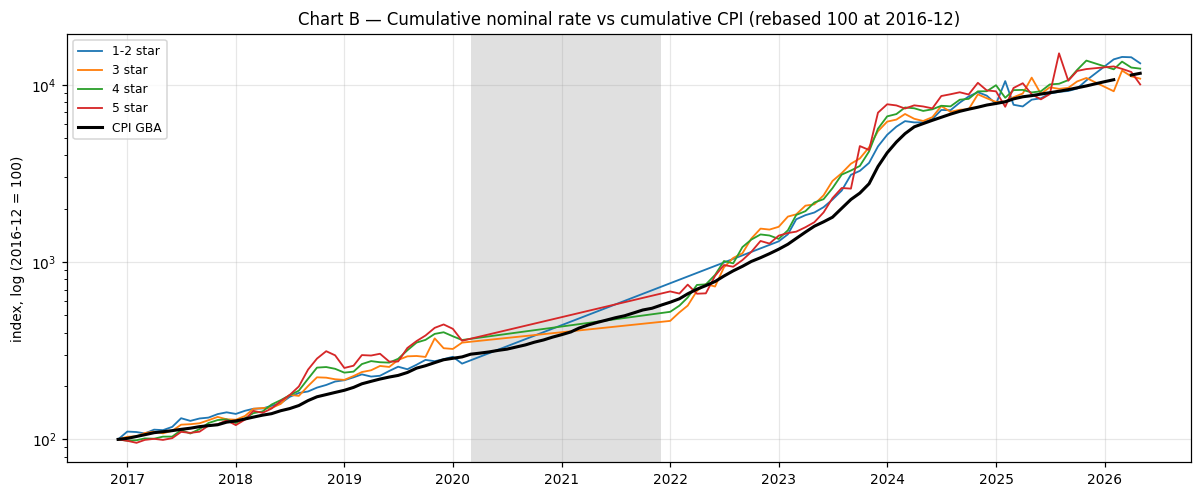

In [8]:
piv = df.pivot_table(index="date", columns="hotel_category", values="average_rate")
cpi_lvl = df.groupby("date")["cpi_gba"].first()
fig, ax = plt.subplots(figsize=(11, 4.6))
b0 = piv.first_valid_index()
for cat in CORE:
    s = piv[cat].dropna()
    ax.plot(s.index, s / s.iloc[0] * 100, lw=1.2, label=LAB[cat])
ax.plot(cpi_lvl.index, cpi_lvl / cpi_lvl.loc[b0] * 100, lw=2, color="k", label="CPI GBA")
ax.axvspan(pd.Timestamp(C.COVID_HOLE_START), pd.Timestamp(C.COVID_HOLE_END),
           color="0.6", alpha=.3, lw=0)
ax.set_yscale("log")
ax.set_title("Chart B — Cumulative nominal rate vs cumulative CPI (rebased 100 at 2016-12)")
ax.set_ylabel("index, log (2016-12 = 100)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "05_chartB_cumulative_passthrough.png")
LOG.log("figure", "05_chartB_cumulative_passthrough.png"); plt.show()

In [9]:
LOG.flush()
print("05 complete.")

05 complete.
